# Study 771 — Box-Office-Bomb 🎬💣

*For the curious.* When a Disney tentpole belly-flops — *John Carter*, *The Lone Ranger*, *The Marvels*, *Snow White* — the reflex trade is obvious: **sell the studio.** A nine-figure write-down is a public humiliation, so the stock should sag once the disappointing weekend is known. We put 16 genuinely notorious Disney bombs (2012→2025) on the stand and asked the tape: **does DIS actually fall after a flop?** The answer is a shrug — the right direction, far too faint to trade.

## The claim, and why it's a clean test

A wide release opens on a known Friday; the *weekend* box-office number is public by Sunday/Monday. So the first session at which 'it flopped' is common knowledge is the **Monday after opening** — a *short DIS that Monday, cover K sessions later* rule is calendar-known and zero-look-ahead. We measure DIS's **abnormal** return (DIS − SPY, total-return) so we're not just measuring the market.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from box_office_bomb import data as dt, strategy as st

if not dt.have_real():
    print("cache miss -> fetching DIS + SPY once (needs network)")
    dt.fetch()
prices = dt.load_real()
ev = st.build_event_table(prices, cost_bps=5.0)
inc = ev[ev["included"]]
print(f"panel loaded; {len(inc)} of {len(dt.EVENTS)} flops resolved")


panel loaded; 16 of 16 flops resolved


## The flop calendar we test (hardcoded from Box Office Mojo / studio releases)

In [2]:
pd.DataFrame(dt.EVENTS, columns=['title', 'opening_date'])

,title,opening_date
0,John Carter,2012-03-09
1,The Lone Ranger,2013-07-03
2,Tomorrowland,2015-05-22
3,The BFG,2016-07-01
4,A Wrinkle in Time,2018-03-09
5,Nutcracker and Four Realms,2018-11-02
6,Dark Phoenix,2019-06-07
7,West Side Story,2021-12-10
8,Lightyear,2022-06-17
9,Strange World,2022-11-23


## The picture: mean cumulative abnormal return around the flop

Offset 0 is the anchor (the Monday after the opening weekend, when the flop is public). Left of zero is the pre-release drift; right of zero is the post-flop window — the 'sell the news'.

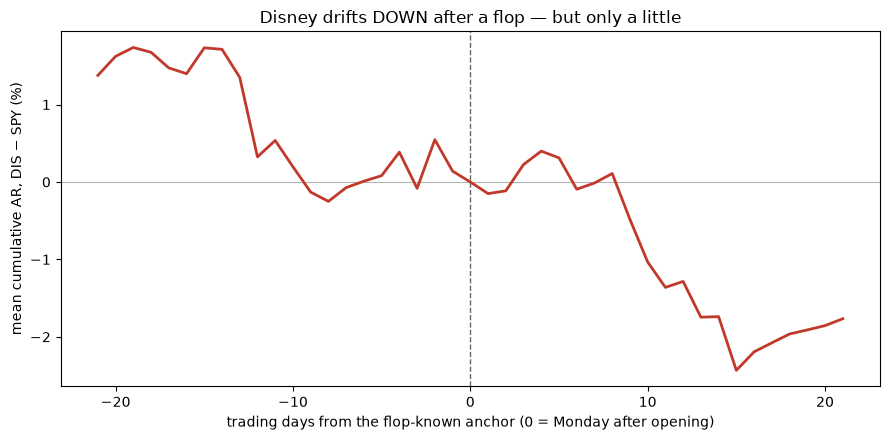

In [3]:
car = st.car_path(ev, prices)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axvline(0, color='0.4', lw=1, ls='--')
ax.axhline(0, color='0.7', lw=0.8)
ax.plot(car.index, car.values * 100, color='#c0392b', lw=2)
ax.set_xlabel('trading days from the flop-known anchor (0 = Monday after opening)')
ax.set_ylabel('mean cumulative AR, DIS − SPY (%)')
ax.set_title('Disney drifts DOWN after a flop — but only a little')
plt.tight_layout(); plt.show()

## The numbers

| window | mean AR | *t* | up rate |
|---|--:|--:|--:|
| 2-week post | **-1.03%** | **-1.53** | 9/16 |
| 1-month post | **-1.77%** | **-1.62** | 7/16 |
| 2-week pre | +0.00% | +0.00 | 10/16 |
| 1-month pre | -1.11% | -0.81 | 8/16 |

The folklore points the *right way*: after a flop DIS under-performs SPY by 1.03% over two weeks and 1.77% over a month, and both cuts carry a negative *t*. But neither clears significance (|*t*| ≈ 1.5–1.6), and the up-rate is a coin-flip. A whiff, not a signal.

In [4]:
rows = [('2wk post','post_s'),('1mo post','post_l'),('2wk pre','pre_s'),('1mo pre','pre_l')]
for label, col in rows:
    s = st.one_sample_t(inc[col].values); hr = st.hit_rate(inc[col].values)
    print(f'{label:<9s} n={s["n"]:2d}  mean={s["mean"]*100:+.3f}%  t={s["t"]:+.3f}  up {hr["k"]}/{hr["n"]}')

2wk post  n=16  mean=-1.034%  t=-1.533  up 9/16
1mo post  n=16  mean=-1.767%  t=-1.622  up 7/16
2wk pre   n=16  mean=+0.001%  t=+0.001  up 10/16
1mo pre   n=16  mean=-1.109%  t=-0.809  up 8/16


## So what?

Selling Disney after a notorious flop is *directionally* right — the stock does mildly lag the market afterwards — but the effect is too small and too noisy (|*t*| ≈ 1.5, placebo p ≈ 0.15) to distinguish from Disney's ordinary underperformance vs SPY, and a 16-event, once-a-year short is a curiosity, not a strategy. Verdict: **Weak signal, Mirage tradability.** The quants' notebook has the placebo, the jackknife, the costed short leg and the synthetic control.